# mlp

## 1.import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## 2.load data

In [2]:
from preprocessing_22 import load_data_scaled

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_scaled()

In [ ]:
# build the model
model = Sequential([
    
    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\nabia\ALL_PROJECTS\ML_Project\venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# train the model
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,

    batch_size=1024,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7915 - loss: 0.4441 - val_accuracy: 0.8354 - val_loss: 0.3691
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8286 - loss: 0.3839 - val_accuracy: 0.8382 - val_loss: 0.3611
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8324 - loss: 0.3755 - val_accuracy: 0.8396 - val_loss: 0.3590
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8347 - loss: 0.3708 - val_accuracy: 0.8404 - val_loss: 0.3556
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8358 - loss: 0.3691 - val_accuracy: 0.8414 - val_loss: 0.3547
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8369 - loss: 0.3673 - val_accuracy: 0.8416 - val_loss: 0.3541
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8376 - loss: 0.3657 - val_accuracy: 0.8423 - val_loss: 0.3540
Epoch 8/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8382 - loss: 0.3645 - val_acc

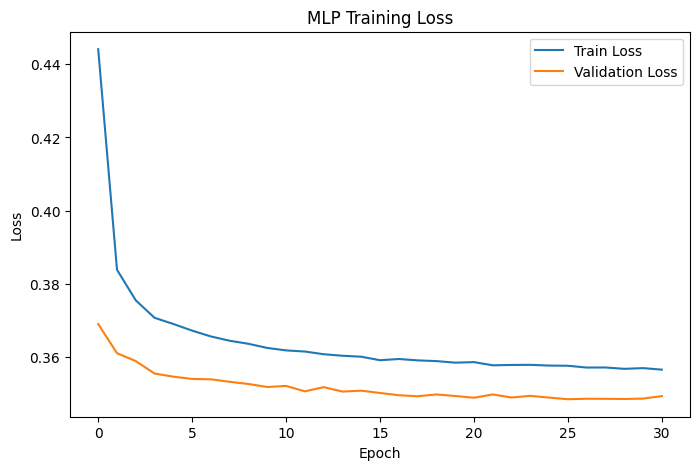

In [ ]:
# plot training history to visualize training loss
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.legend()

plt.show()

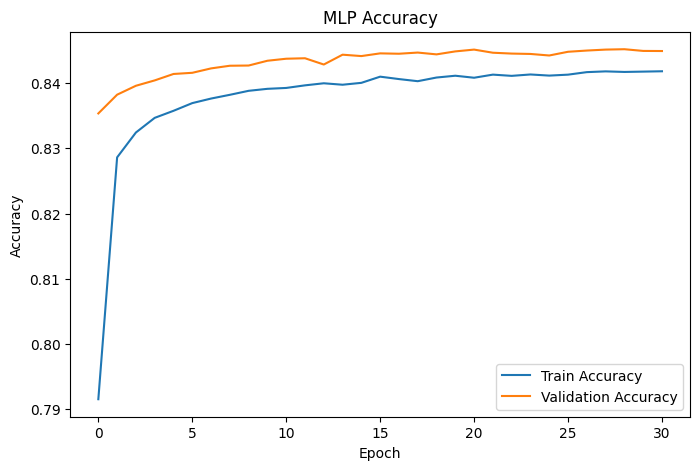

In [ ]:
# plot accuracy history to visualize training accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("MLP Accuracy")

plt.legend()

plt.show()

In [ ]:
# evaluate the model on the test set
y_prob = model.predict(X_test)

y_prob = y_prob.flatten()

y_pred = (
    y_prob > 0.5
).astype(int)

3836/3836 ━━━━━━━━━━━━━━━━━━━━ 3s 677us/step


In [ ]:
# calculate evaluation metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.8426
Precision: 0.8013
Recall   : 0.7174
F1 Score : 0.7570
ROC AUC  : 0.9105


In [ ]:
# classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.91      0.88     80802
           1       0.80      0.72      0.76     41934

    accuracy                           0.84    122736
   macro avg       0.83      0.81      0.82    122736
weighted avg       0.84      0.84      0.84    122736



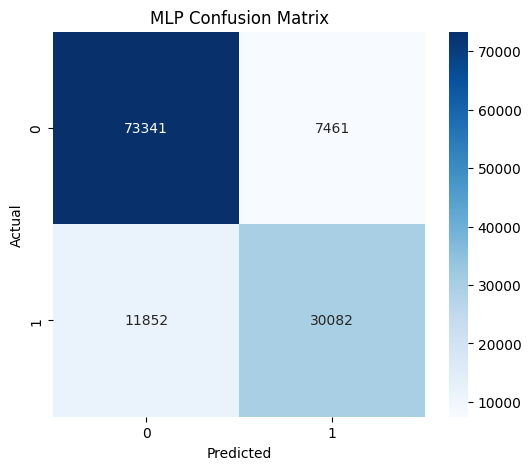

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "MLP Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## roc curve

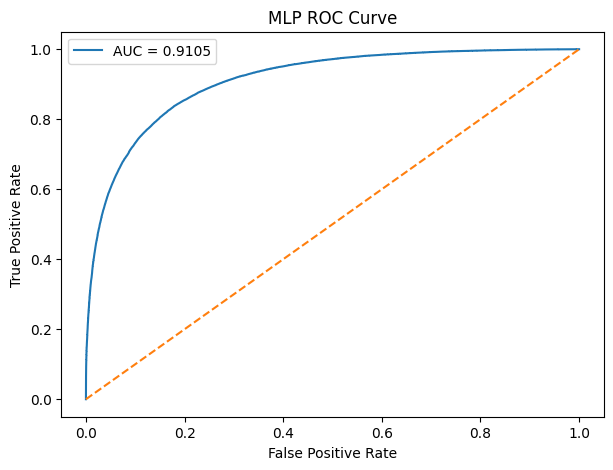

In [ ]:

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "MLP ROC Curve"
)

plt.legend()

plt.show()

In [14]:
model.save(
    "../models/higgs_mlp.keras"
)